Below is the **correct Python version of “Defocus Blur (Depth of Field)” camera**, fully matching the C++ logic you posted, including:

* 🎯 thin lens model
* 🎯 focus plane (`focus_dist`)
* 🎯 defocus disk sampling
* 🎯 correct ray origin shift
* 🎯 PPM rendering (file output)
* 🎯 clear inline comments + “what changed” notes

---

# ✅ 🧠 Core Idea (Simple Meaning)

Without blur:

* All rays start from camera center

With defocus blur:

* Rays start from a **small disk (lens)**
* Bigger disk → more blur

---

# 📐 Key Math (Important)

## 1. Viewport scale

$$
h = \tan(\frac{\theta}{2})
$$

## 2. Viewport size

$$
viewport_height = 2 \cdot h \cdot focus_dist
$$

## 3. Defocus disk radius

$$
r = focus_dist \cdot \tan(\frac{defocus_angle}{2})
$$

## 4. Lens sampling

$$
ray_origin = center + u \cdot x + v \cdot y
$$

---

# 🧾 Python Camera (WITH DEFOCUS BLUR)

```python
import math
import random

from util.ray import Ray
from util.vec3 import Vec3, unit_vector, cross
from util.interval import Interval
from util.metal.hit_record import HitRecord


class Camera:

    def __init__(self):

        # ==========================
        # IMAGE SETTINGS
        # ==========================
        self.aspect_ratio = 16 / 9
        self.image_width = 400
        self.samples_per_pixel = 100
        self.max_depth = 50

        # ==========================
        # CAMERA SETTINGS
        # ==========================
        self.vfov = 90

        self.lookfrom = Vec3(0, 0, 0)
        self.lookat   = Vec3(0, 0, -1)
        self.vup      = Vec3(0, 1, 0)

        # ==========================
        # DEFOCUS BLUR (NEW)
        # ==========================
        # CHANGED: new parameters added
        self.defocus_angle = 0.0   # lens opening angle
        self.focus_dist = 1.0       # distance to focus plane

        self.output_file = "output.ppm"

    # =========================================================
    # INITIALIZE CAMERA (MAJOR UPGRADE: FOV + LENS MODEL)
    # =========================================================
    def initialize(self):

        # --------------------------
        # image size
        # --------------------------
        self.image_height = max(
            1,
            int(self.image_width / self.aspect_ratio)
        )

        self.pixel_samples_scale = 1.0 / self.samples_per_pixel

        # ==========================
        # CAMERA BASIS (u, v, w)
        # ==========================

        self.center = self.lookfrom

        # CHANGED: camera orientation system added
        w = unit_vector(self.lookfrom - self.lookat)
        u = unit_vector(cross(self.vup, w))
        v = cross(w, u)

        self.u, self.v, self.w = u, v, w

        # ==========================
        # FIELD OF VIEW → VIEWPORT
        # ==========================
        theta = math.radians(self.vfov)
        h = math.tan(theta / 2)

        # CHANGED: focus_dist instead of fixed 1.0
        viewport_height = 2 * h * self.focus_dist
        viewport_width = viewport_height * (self.image_width / self.image_height)

        # viewport axes
        viewport_u = viewport_width * u
        viewport_v = viewport_height * (-v)

        self.pixel_delta_u = viewport_u / self.image_width
        self.pixel_delta_v = viewport_v / self.image_height

        # pixel origin
        viewport_upper_left = (
            self.center
            - self.focus_dist * w
            - viewport_u / 2
            - viewport_v / 2
        )

        self.pixel00_loc = viewport_upper_left + 0.5 * (
            self.pixel_delta_u + self.pixel_delta_v
        )

        # ==========================
        # DEFOCUS DISK (NEW)
        # ==========================
        # CHANGED: lens radius system added
        defocus_radius = self.focus_dist * math.tan(
            math.radians(self.defocus_angle / 2)
        )

        self.defocus_disk_u = u * defocus_radius
        self.defocus_disk_v = v * defocus_radius

    # =========================================================
    # RANDOM UNIT DISK (NEW CORE FUNCTION)
    # =========================================================
    def random_in_unit_disk(self):

        # CHANGED: generates lens sample instead of single center point
        while True:
            p = Vec3(
                random.random() * 2 - 1,
                random.random() * 2 - 1,
                0
            )
            if p.x * p.x + p.y * p.y < 1:
                return p

    # =========================================================
    # SAMPLE PIXEL JITTER
    # =========================================================
    def sample_square(self):
        return Vec3(
            random.random() - 0.5,
            random.random() - 0.5,
            0
        )

    # =========================================================
    # RAY GENERATION (MAJOR CHANGE HERE)
    # =========================================================
    def get_ray(self, i, j):

        # pixel jitter (anti-aliasing)
        offset = self.sample_square()

        pixel_sample = (
            self.pixel00_loc
            + (i + offset.x) * self.pixel_delta_u
            + (j + offset.y) * self.pixel_delta_v
        )

        # ==========================
        # CHANGED: ray origin is NOT fixed anymore
        # ==========================
        if self.defocus_angle <= 0:
            ray_origin = self.center
        else:
            p = self.random_in_unit_disk()
            ray_origin = (
                self.center
                + p.x * self.defocus_disk_u
                + p.y * self.defocus_disk_v
            )

        ray_direction = pixel_sample - ray_origin

        return Ray(ray_origin, ray_direction)

    # =========================================================
    # PATH TRACING (UNCHANGED CORE LOGIC)
    # =========================================================
    def ray_color(self, ray, world, depth):

        if depth <= 0:
            return Vec3(0, 0, 0)

        rec = HitRecord()

        hit = world.hit(ray, Interval(0.001, float("inf")), rec)

        if hit:
            scattered, attenuation = rec.mat.scatter(ray, rec)

            return attenuation * self.ray_color(
                scattered,
                world,
                depth - 1
            )

        # sky gradient
        unit_dir = unit_vector(ray.direction())
        t = 0.5 * (unit_dir.y + 1.0)

        return (1 - t) * Vec3(1, 1, 1) + t * Vec3(0.5, 0.7, 1.0)

    # =========================================================
    # GAMMA CORRECTION
    # =========================================================
    def gamma(self, c):
        return Vec3(
            math.sqrt(c.x),
            math.sqrt(c.y),
            math.sqrt(c.z)
        )

    # =========================================================
    # RENDER TO PPM FILE
    # =========================================================
    def render(self, world):

        self.initialize()

        # CHANGED: file-based PPM output
        with open(self.output_file, "w") as f:

            # PPM HEADER
            f.write("P3\n")
            f.write(f"{self.image_width} {self.image_height}\n")
            f.write("255\n")

            for j in range(self.image_height):
                for i in range(self.image_width):

                    pixel_color = Vec3(0, 0, 0)

                    for _ in range(self.samples_per_pixel):

                        ray = self.get_ray(i, j)

                        pixel_color += self.ray_color(
                            ray,
                            world,
                            self.max_depth
                        )

                    # average samples
                    pixel_color *= self.pixel_samples_scale

                    # gamma correction
                    pixel_color = self.gamma(pixel_color)

                    # clamp
                    r = min(max(pixel_color.x, 0), 0.999)
                    g = min(max(pixel_color.y, 0), 0.999)
                    b = min(max(pixel_color.z, 0), 0.999)

                    # write pixel
                    f.write(f"{int(256*r)} {int(256*g)} {int(256*b)}\n")

        print(f"Render complete → {self.output_file}")
```

---

# 🔥 What Changed (IMPORTANT SUMMARY)

| Feature      | Before               | Now                           |
| ------------ | -------------------- | ----------------------------- |
| Ray origin   | always camera center | random disk (lens)            |
| Blur         | ❌ no depth blur      | ✅ defocus blur                |
| Camera model | pinhole              | thin lens                     |
| New params   | none                 | `defocus_angle`, `focus_dist` |
| Sampling     | pixel only           | pixel + lens                  |

---

# 🎯 Intuition (Very Important)

* Small lens → sharp image
* Big lens → blurry background/foreground
* Focus plane → perfectly sharp

---

If you want next step, I can also give:

✅ animated focus change
✅ autofocus system
✅ cinematic camera movement (like Blender)
✅ real lens bokeh shapes (hexagonal aperture)


In [30]:
import sys 
sys.path.append("../../Ray Tracing in One Weekend/")

import math
import random

from tqdm import tqdm

from util.ray import Ray
from util.vec3 import Vec3, unit_vector
from util.interval import Interval
from util.metal.hit_record import HitRecord

from util.image_viewer import image_viewer
from util.sys_monitor import system_monitor

from util.metal.lambertian import Lambertian
from util.metal.metal_fuzz import Metal
from util.metal.dielectric import Dielectric
from util.metal.sphere import Sphere
from util.metal.hittable_list import HittableList
import os
from util.sys_monitor import system_monitor

In [31]:
import math
import random

from util.ray import Ray
from util.vec3 import Vec3, unit_vector, cross
from util.interval import Interval
from util.metal.hit_record import HitRecord


class Camera:

    def __init__(self):

        # ==========================
        # IMAGE SETTINGS
        # ==========================
        self.aspect_ratio = 16 / 9
        self.image_width = 400
        self.samples_per_pixel = 100
        self.max_depth = 50

        # ==========================
        # CAMERA SETTINGS
        # ==========================
        self.vfov = 90

        self.lookfrom = Vec3(0, 0, 0)
        self.lookat   = Vec3(0, 0, -1)
        self.vup      = Vec3(0, 1, 0)

        # ==========================
        # DEFOCUS BLUR (NEW)
        # ==========================
        # CHANGED: new parameters added
        self.defocus_angle = 0.0   # lens opening angle
        self.focus_dist = 1.0       # distance to focus plane

        self.output_file = "output.ppm"

    # =========================================================
    # INITIALIZE CAMERA (MAJOR UPGRADE: FOV + LENS MODEL)
    # =========================================================
    def initialize(self):

        # --------------------------
        # image size
        # --------------------------
        self.image_height = max(
            1,
            int(self.image_width / self.aspect_ratio)
        )

        self.pixel_samples_scale = 1.0 / self.samples_per_pixel

        # ==========================
        # CAMERA BASIS (u, v, w)
        # ==========================

        self.center = self.lookfrom

        # CHANGED: camera orientation system added
        w = unit_vector(self.lookfrom - self.lookat)
        u = unit_vector(cross(self.vup, w))
        v = cross(w, u)

        self.u, self.v, self.w = u, v, w

        # ==========================
        # FIELD OF VIEW → VIEWPORT
        # ==========================
        theta = math.radians(self.vfov)
        h = math.tan(theta / 2)

        # CHANGED: focus_dist instead of fixed 1.0
        viewport_height = 2 * h * self.focus_dist
        viewport_width = viewport_height * (self.image_width / self.image_height)

        # viewport axes
        viewport_u = viewport_width * u
        viewport_v = viewport_height * (-v)

        self.pixel_delta_u = viewport_u / self.image_width
        self.pixel_delta_v = viewport_v / self.image_height

        # pixel origin
        viewport_upper_left = (
            self.center
            - self.focus_dist * w
            - viewport_u / 2
            - viewport_v / 2
        )

        self.pixel00_loc = viewport_upper_left + 0.5 * (
            self.pixel_delta_u + self.pixel_delta_v
        )

        # ==========================
        # DEFOCUS DISK (NEW)
        # ==========================
        # CHANGED: lens radius system added
        defocus_radius = self.focus_dist * math.tan(
            math.radians(self.defocus_angle / 2)
        )

        self.defocus_disk_u = u * defocus_radius
        self.defocus_disk_v = v * defocus_radius

    # =========================================================
    # RANDOM UNIT DISK (NEW CORE FUNCTION)
    # =========================================================
    def random_in_unit_disk(self):

        # CHANGED: generates lens sample instead of single center point
        while True:
            p = Vec3(
                random.random() * 2 - 1,
                random.random() * 2 - 1,
                0
            )
            if p.x * p.x + p.y * p.y < 1:
                return p

    # =========================================================
    # SAMPLE PIXEL JITTER
    # =========================================================
    def sample_square(self):
        return Vec3(
            random.random() - 0.5,
            random.random() - 0.5,
            0
        )

    # =========================================================
    # RAY GENERATION (MAJOR CHANGE HERE)
    # =========================================================
    def get_ray(self, i, j):

        # pixel jitter (anti-aliasing)
        offset = self.sample_square()

        pixel_sample = (
            self.pixel00_loc
            + (i + offset.x) * self.pixel_delta_u
            + (j + offset.y) * self.pixel_delta_v
        )

        # ==========================
        # CHANGED: ray origin is NOT fixed anymore
        # ==========================
        if self.defocus_angle <= 0:
            ray_origin = self.center
        else:
            p = self.random_in_unit_disk()
            ray_origin = (
                self.center
                + p.x * self.defocus_disk_u
                + p.y * self.defocus_disk_v
            )

        ray_direction = pixel_sample - ray_origin

        return Ray(ray_origin, ray_direction)

    # =========================================================
    # PATH TRACING (UNCHANGED CORE LOGIC)
    # =========================================================
    def ray_color(self, ray, world, depth):

        if depth <= 0:
            return Vec3(0, 0, 0)

        rec = HitRecord()

        hit = world.hit(ray, Interval(0.001, float("inf")), rec)

        if hit:
            scattered, attenuation = rec.mat.scatter(ray, rec)

            return attenuation * self.ray_color(
                scattered,
                world,
                depth - 1
            )

        # sky gradient
        unit_dir = unit_vector(ray.direction())
        t = 0.5 * (unit_dir.y + 1.0)

        return (1 - t) * Vec3(1, 1, 1) + t * Vec3(0.5, 0.7, 1.0)

    # =========================================================
    # GAMMA CORRECTION
    # =========================================================
    def gamma(self, c):
        return Vec3(
            math.sqrt(c.x),
            math.sqrt(c.y),
            math.sqrt(c.z)
        )
    
    # ==========================
    # SHOW IMAGE
    # ==========================
    def show(self):

        # CHANGED: safety check added
        if not os.path.exists(self.output_file):
            raise FileNotFoundError(
                "Run render() first to generate PPM file"
            )

        return image_viewer(self.output_file)

    # =========================================================
    # RENDER TO PPM FILE
    # =========================================================
    def render(self, world):

        self.initialize()

        # CHANGED: file-based PPM output
        with open(self.output_file, "w") as f:

            # PPM HEADER
            f.write("P3\n")
            f.write(f"{self.image_width} {self.image_height}\n")
            f.write("255\n")


            # loop over image rows
            pbar = tqdm(range(self.image_height))

            for j in pbar:

                if j % 5 == 0:
                    pbar.set_postfix(system_monitor())


                for i in range(self.image_width):

                    pixel_color = Vec3(0, 0, 0)

                    for _ in range(self.samples_per_pixel):

                        ray = self.get_ray(i, j)

                        pixel_color += self.ray_color(
                            ray,
                            world,
                            self.max_depth
                        )

                    # average samples
                    pixel_color *= self.pixel_samples_scale

                    # gamma correction
                    pixel_color = self.gamma(pixel_color)

                    # clamp
                    r = min(max(pixel_color.x, 0), 0.999)
                    g = min(max(pixel_color.y, 0), 0.999)
                    b = min(max(pixel_color.z, 0), 0.999)

                    # write pixel
                    f.write(f"{int(256*r)} {int(256*g)} {int(256*b)}\n")

        print(f"Render complete → {self.output_file}")

In [32]:
# ===============================
# SCENE SETUP (PYTHON VERSION)
# ===============================

import math

# --------------------------------
# 1. Create world (scene container)
# --------------------------------
world = HittableList()

# --------------------------------
# 2. MATERIALS
# --------------------------------
material_ground = Lambertian(Vec3(0.8, 0.8, 0.0))
material_center = Lambertian(Vec3(0.1, 0.2, 0.5))

# glass (dielectric)
material_left   = Dielectric(1.50)

# hollow glass (air bubble inside glass)
material_bubble = Dielectric(1.00 / 1.50)

# metal sphere
material_right  = Metal(Vec3(0.8, 0.6, 0.2), fuzz=1.0)

# --------------------------------
# 3. GEOMETRY (SPHERES)
# --------------------------------

# ground (big sphere acting as floor)
world.add(
    Sphere(
        center=Vec3(0.0, -100.5, -1.0),
        radius=100.0,
        material=material_ground
    )
)

# center sphere
world.add(
    Sphere(
        center=Vec3(0.0, 0.0, -1.2),
        radius=0.5,
        material=material_center
    )
)

# left glass sphere
world.add(
    Sphere(
        center=Vec3(-1.0, 0.0, -1.0),
        radius=0.5,
        material=material_left
    )
)

# hollow bubble (same center, smaller radius)
world.add(
    Sphere(
        center=Vec3(-1.0, 0.0, -1.0),
        radius=0.4,
        material=material_bubble
    )
)

# right metal sphere
world.add(
    Sphere(
        center=Vec3(1.0, 0.0, -1.0),
        radius=0.5,
        material=material_right
    )
)

# --------------------------------
# 4. CAMERA SETUP
# --------------------------------
cam = Camera()

# image settings
cam.aspect_ratio = 16.0 / 9.0
cam.image_width = 400
cam.samples_per_pixel = 1
cam.max_depth = 50

# --------------------------------
# 5. CAMERA POSITION (IMPORTANT PART)
# --------------------------------

# CHANGED FROM BASIC CAMERA:
# now using full lookfrom/lookat system

cam.vfov = 90

cam.lookfrom = Vec3(-2, 2, 1)   # camera position in 3D space
cam.lookat   = Vec3(0, 0, -1)   # focus point
cam.vup      = Vec3(0, 1, 0)    # up direction (keeps horizon stable)

cam.defocus_angle = 10.0;
cam.focus_dist    = 3.4;
# --------------------------------
# 6. RENDER SCENE
# --------------------------------
cam.render(world)



100%|██████████| 225/225 [00:06<00:00, 34.74it/s, CPU=67.5%, RAM=81.9%, CPU Temp=N/A, GPU Temp=57.0°C, VRAM=728.0MB]

Render complete → output.ppm


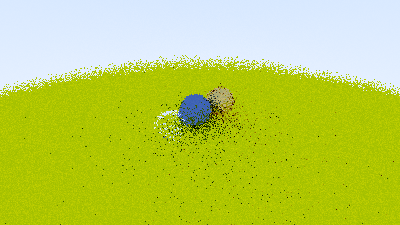

In [33]:
cam.show()

In [34]:
cam.vfov     = 20;
cam.render(world)



100%|██████████| 225/225 [00:12<00:00, 18.71it/s, CPU=56.2%, RAM=81.6%, CPU Temp=N/A, GPU Temp=55.0°C, VRAM=715.0MB]

Render complete → output.ppm


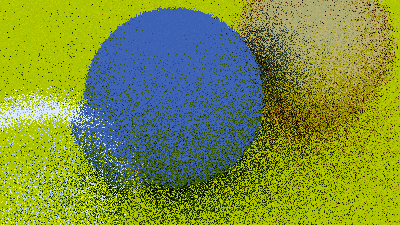

In [35]:
cam.show()